# Calculating hosting capacity for SDG&E
Use the hosting capacity calculation methodology from Brockway et al (2021) to calculate the hosting capacity for SDG&E at the census tract level. 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt

### Load in data

In [11]:
# read in feederline data
sdge_feederlines = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sandiego_grid/gen_cap_lines_sdge.geojson")

# read in multifamily data
sdge_multifamily = gpd.read_file("../../../../capstone/electrigrid/data/building_zillow_merges/sdcounty_buildings/multi_summed_units_sd.geojson")

# read in the single family data  
sdge_singlefamily = gpd.read_file("../../../../capstone/electrigrid/data/building_zillow_merges/sdcounty_buildings/sdge_singlefamily.geojson")

# read in the census tract data
census_tracts = gpd.read_file("../../../../capstone/electrigrid/data/census/tl_2025_06_tract/tl_2025_06_tract.shp")

# load in shapefile for extent of SDGE
utility_ter = gpd.read_file("../../../../capstone/electrigrid/data/utilities/IOU_shapefiles.geojson")

# Clip the census tract data to SDGE 

In [12]:
# view the utility data frame
utility_ter.head()

,OBJECTID,Acronym,Utility,AgencyNum,Type,URL,Phone,Address,HIFLD_ID,Sales_GWh_1990,...,Sales_GWh_2019,Sales_GWh_2020,Sales_GWh_2021,Sales_GWh_2022,Sales_GWh_2023,Sales_GWh_2024,Sales_GWh_2025,OnlineName,Audit,geometry
0,1,,PacifiCorp,71026.0,IOU,https://www.pacificorp.com/,(503) 813-5000,"825 NE Multnomah Street, Suite 2000 Portland, ...",14354,736.955156,...,742.775668,762.225388,794.358238,801.710660,774.312862,None,None,None,None,"MULTIPOLYGON Z (((-124.20211 41.74485 0.00000,..."
1,2,,Liberty Utilities,84372.0,IOU,http://www.libertyutilities.com/west/?region=C...,800.782.2506,"933 Eloise Ave South Lake Tahoe, CA 96150",57483,426.373385,...,564.199718,553.802343,559.771745,558.609575,539.033661,None,None,None,None,"POLYGON Z ((-120.08497 39.70865 0.00000, -120...."
2,3,SCE,Southern California Edison,86250.0,IOU,https://www.sce.com/,(818) 302-1212,"2244 Walnut Grove Avenue Rosemead, CA 91770-3714",17609,71016.547845,...,81183.999994,81054.000005,81132.999996,82971.000004,76840.077169,None,None,None,None,"MULTIPOLYGON Z (((-118.60361 33.47801 0.00000,..."
3,4,PG&E,Pacific Gas & Electric Company,71021.0,IOU,https://www.pge.com/,(415) 973-7000,"77 Beale Street San Francisco, CA 94105",14328,70036.326445,...,78389.925613,78518.835139,78438.000003,77887.000005,72932.833237,None,None,None,None,"MULTIPOLYGON Z (((-120.87195 35.21664 0.00000,..."
4,5,SDG&E,San Diego Gas & Electric,80402.0,IOU,https://www.sdge.com/,(619) 696-2000,"P.O. Box 129831 San Diego, CA 92112-9831",16609,14396.900280,...,17681.971922,17444.765817,17444.765817,17867.262050,16982.218070,None,None,None,None,"MULTIPOLYGON Z (((-117.12961 32.62193 0.00000,..."


In [13]:
# filter to only sdge 
shape_sdge = utility_ter[utility_ter['Acronym'] == 'SDG&E'] 

# check the crs
shape_sdge = shape_sdge.to_crs('EPSG:3310')

In [14]:
census_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,065,042516,06065042516,1400000US06065042516,425.16,Census Tract 425.16,G5020,S,973130,0,+33.9227363,-117.2393879,"POLYGON ((-117.24375 33.92818, -117.24323 33.9..."
1,06,065,042716,06065042716,1400000US06065042716,427.16,Census Tract 427.16,G5020,S,2698784,711913,+33.6865062,-117.2551285,"POLYGON ((-117.27209 33.68473, -117.27117 33.6..."
2,06,065,042717,06065042717,1400000US06065042717,427.17,Census Tract 427.17,G5020,S,6425166,145210,+33.6997108,-117.2534257,"POLYGON ((-117.26908 33.70438, -117.26882 33.7..."
3,06,065,042902,06065042902,1400000US06065042902,429.02,Census Tract 429.02,G5020,S,43393952,0,+33.7493422,-117.3068291,"POLYGON ((-117.34733 33.78247, -117.34731 33.7..."
4,06,065,042903,06065042903,1400000US06065042903,429.03,Census Tract 429.03,G5020,S,44642454,0,+33.8027798,-117.3133054,"POLYGON ((-117.36332 33.82940, -117.36331 33.8..."


In [18]:
# change the crs of the census tract data
census_tracts = census_tracts.to_crs('EPSG:3310')

# add a check before performing geospatial clipping
assert census_tracts.crs == shape_sdge.crs

# clip the census tract to the sdge area
census_tracts = census_tracts.clip(shape_sdge)



# Link the homes to the nearest feederline

In [3]:

# change the crs to a projected CRS
sdge_feederlines = sdge_feederlines.to_crs("EPSG:3310")
sdge_singlefamily = sdge_singlefamily.to_crs("EPSG:3310")

# add a check
assert sdge_feederlines.crs == sdge_singlefamily.crs


# index the data
sdge_feederlines.sindex
sdge_singlefamily.sindex

# spatial join
sdge_singlefamily_linked = gpd.sjoin_nearest(sdge_singlefamily, 
                                        sdge_feederlines, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

In [4]:
# change the crs to a projected CRS
sdge_multifamily = sdge_multifamily.to_crs("EPSG:3310")

# add a check
assert sdge_feederlines.crs == sdge_multifamily.crs

# index the data
sdge_feederlines.sindex
sdge_multifamily.sindex

# spatial join
sdge_multifamily_linked = gpd.sjoin_nearest(sdge_multifamily, 
                                        sdge_feederlines, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

# Create line length column

Our data analysis will need length data for each line segment. Let's calculate the lengths.

In [5]:
# create length column in metres
sdge_singlefamily_linked['LENGTH (M)'] = sdge_singlefamily_linked.length
sdge_multifamily_linked['LENGTH (M)'] = sdge_multifamily_linked.length

# Map all of the data sources

<Axes: >

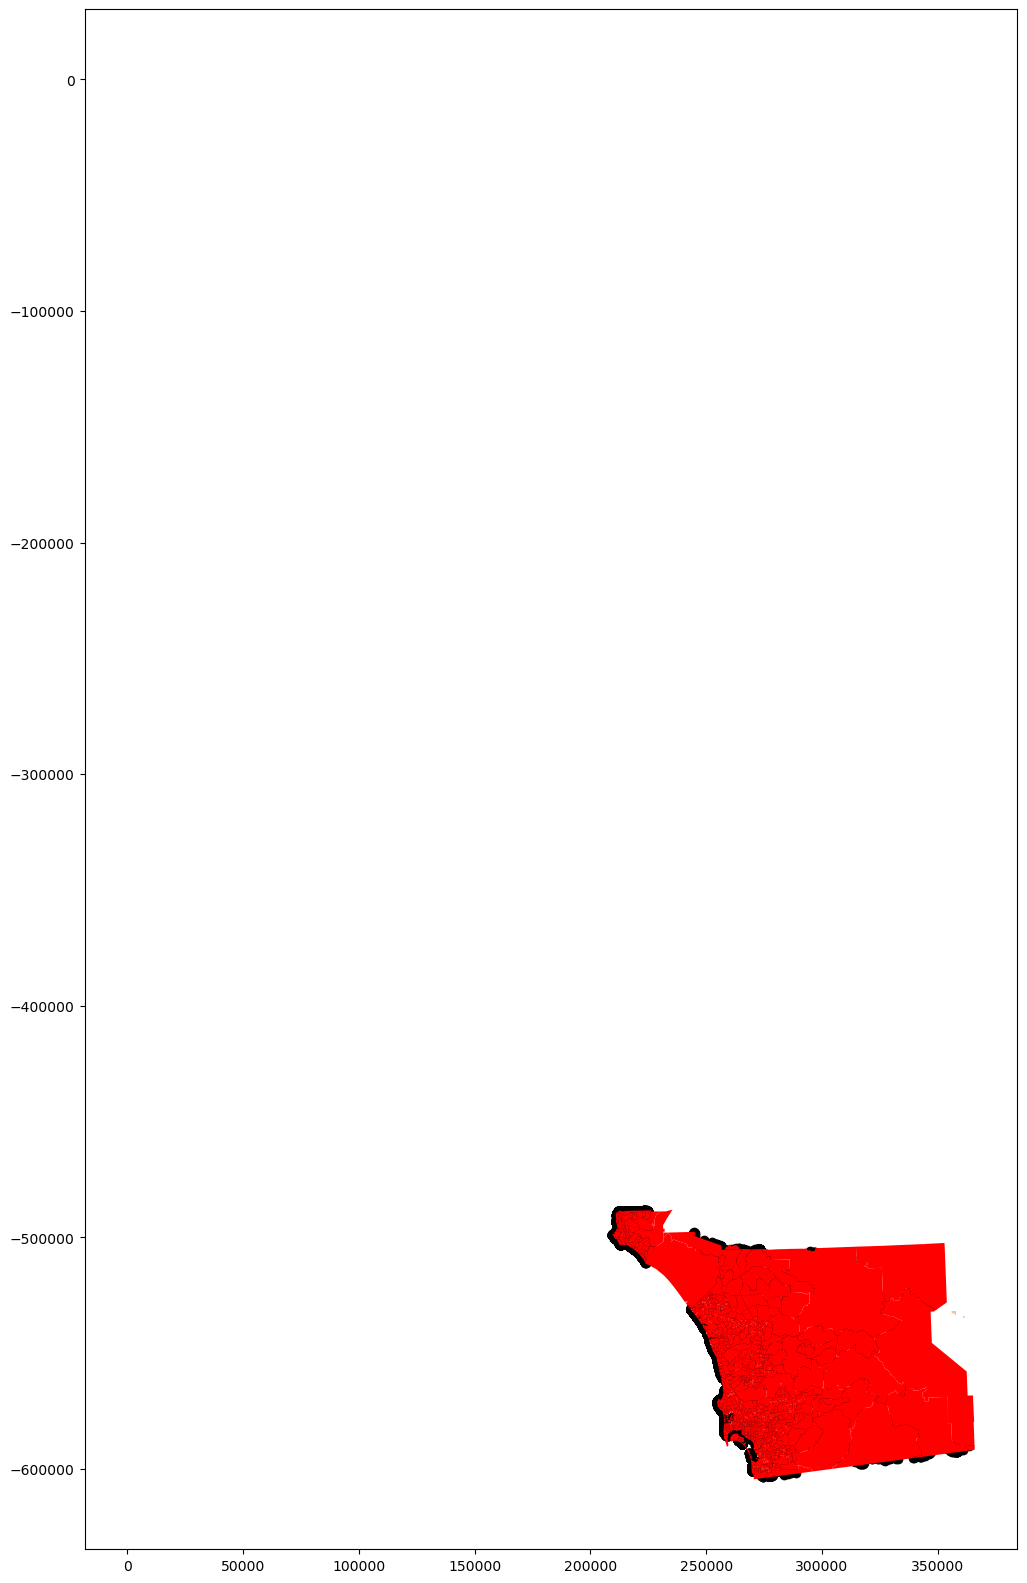

In [19]:
# plot all of the data sources to ensure everything looks accurate 
fig, ax = plt.subplots(figsize=(20, 20))

# ax.axis('off')

sdge_singlefamily_linked.plot(ax=ax, 
                    color='black')

sdge_multifamily_linked.plot(ax=ax, 
                    color='#F6BE9A')

sdge_feederlines.plot(ax=ax, 
                      color='#004643')

census_tracts.plot(ax=ax, 
                    color='red')

<Axes: >

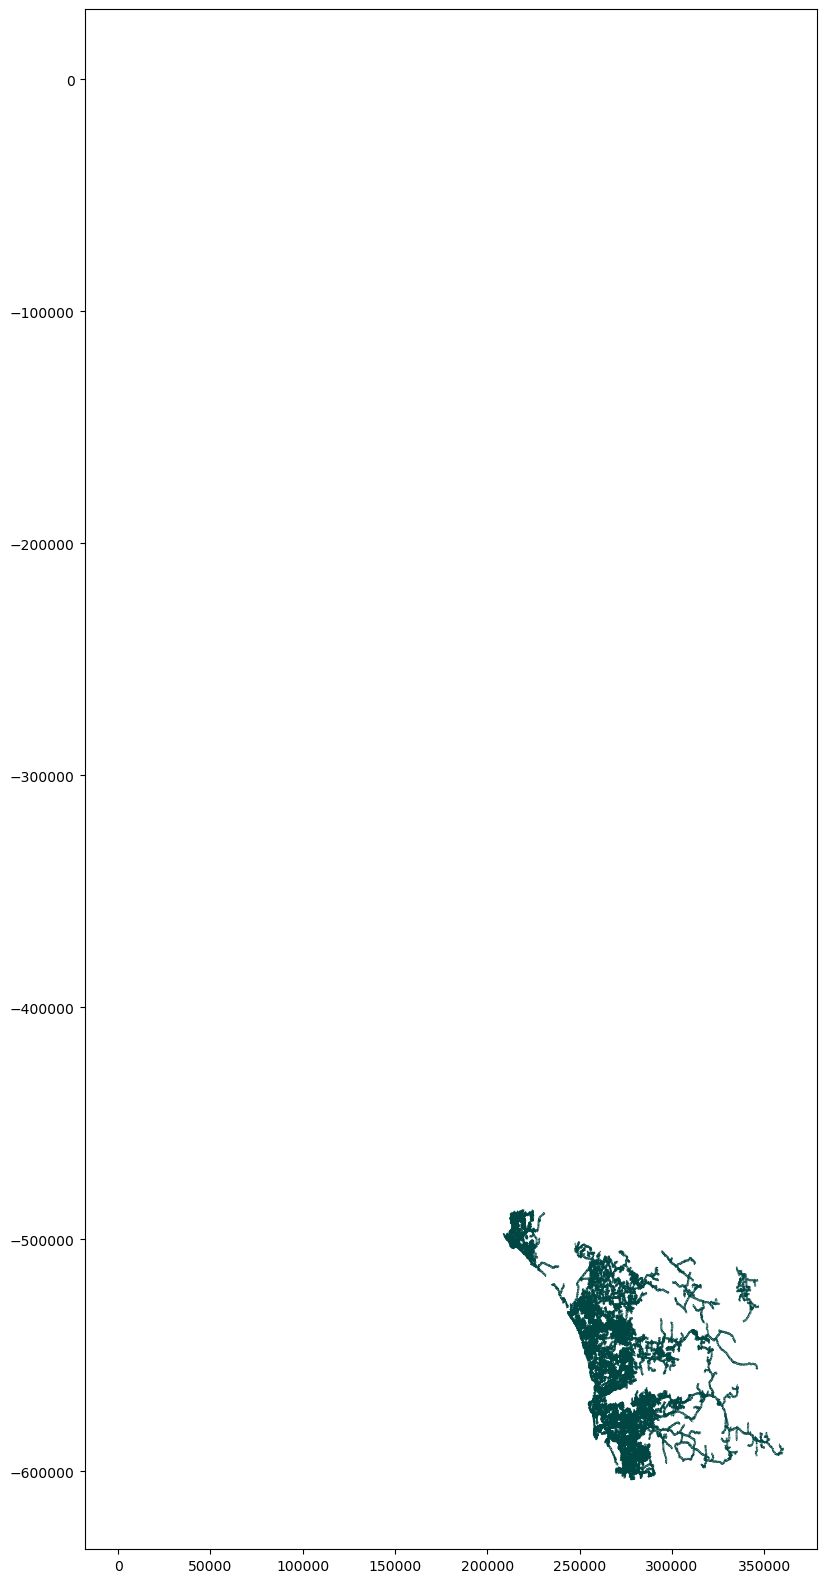

In [ ]:
# plot all of the data sources to ensure everything looks accurate 
fig, ax = plt.subplots(figsize=(20, 20))

# ax.axis('off')

sdge_feederlines.plot(ax=ax, 
                      color='#004643')

